In [1]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {gpus if gpus else 'None — using CPU'}")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

TensorFlow version: 2.20.0
GPUs available: None — using CPU


In [2]:
# ── Paths ─────────────────────────────────────────────────
DATASET_DIR = r"C:\Users\Adit Gupta\OneDrive\Desktop\sem 4\practicum\DS1"
OUTPUT_DIR  = r"C:\Users\Adit Gupta\OneDrive\Desktop\sem 4\practicum\DS1_split"

# ── Hyperparameters ───────────────────────────────────────
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
EPOCHS_FROZEN = 10       # Phase 1
EPOCHS_FINE   = 10       # Phase 2 — kept low to save time
LR_FROZEN     = 1e-3
LR_FINE       = 1e-5

# ── Classes ───────────────────────────────────────────────
CLASS_NAMES   = ["N", "O", "R"]
DISPLAY_NAMES = ["Non-Recyclable", "Organic", "Recyclable"]
NUM_CLASSES   = len(CLASS_NAMES)

MODEL_SAVE_PATH = os.path.join(OUTPUT_DIR, "waste_mobilenetv2.keras")

TRAIN_DIR = os.path.join(OUTPUT_DIR, "TRAIN")
TEST_DIR  = os.path.join(OUTPUT_DIR, "TEST")

In [3]:
# ════════════════════════════════════════════════════════════
# STEP 1 — DATASET SPLIT
# ════════════════════════════════════════════════════════════
TRAIN_RATIO = 0.8
SEED        = 42
random.seed(SEED)

# Only run split if output folder doesn't already exist
if os.path.exists(OUTPUT_DIR):
    print("Split dataset already exists — skipping split ✅")
    print("Delete DS1_split folder and rerun if you want to redo the split.")
else:
    print("Splitting dataset...")
    for cls in CLASS_NAMES:
        all_images = []

        for split in ["TRAIN", "TEST"]:
            folder = os.path.join(DATASET_DIR, split, cls)
            if os.path.exists(folder):
                images = [
                    os.path.join(folder, f)
                    for f in os.listdir(folder)
                    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
                ]
                all_images.extend(images)

        random.shuffle(all_images)
        split_idx  = int(len(all_images) * TRAIN_RATIO)
        train_imgs = all_images[:split_idx]
        test_imgs  = all_images[split_idx:]

        for subset, imgs in [("TRAIN", train_imgs), ("TEST", test_imgs)]:
            out_folder = os.path.join(OUTPUT_DIR, subset, cls)
            os.makedirs(out_folder, exist_ok=True)
            for src in imgs:
                shutil.copy2(src, os.path.join(out_folder, os.path.basename(src)))

        print(f"  {cls}: {len(train_imgs)} train | {len(test_imgs)} test")

    print("Dataset split complete ✅\n")

# Verify counts
print("Verifying split:")
for split in ["TRAIN", "TEST"]:
    print(f"\n  {split}:")
    for cls in CLASS_NAMES:
        count = len(os.listdir(os.path.join(OUTPUT_DIR, split, cls)))
        print(f"    {cls}: {count} images")

Splitting dataset...
  N: 3881 train | 971 test
  O: 11172 train | 2794 test
  R: 11936 train | 2985 test
Dataset split complete ✅

Verifying split:

  TRAIN:
    N: 3881 images
    O: 11172 images
    R: 11936 images

  TEST:
    N: 971 images
    O: 2794 images
    R: 2985 images


In [4]:
# ════════════════════════════════════════════════════════════
# STEP 2 — DATA GENERATORS
# ════════════════════════════════════════════════════════════
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.20,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest",
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=True,
    seed=SEED,
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False,
)

print(f"\nClass indices : {train_gen.class_indices}")
print(f"Train samples : {train_gen.samples}")
print(f"Test  samples : {test_gen.samples}")

Found 26979 images belonging to 3 classes.
Found 6749 images belonging to 3 classes.

Class indices : {'N': 0, 'O': 1, 'R': 2}
Train samples : 26979
Test  samples : 6749


In [5]:
# ════════════════════════════════════════════════════════════
# STEP 3 — CLASS WEIGHTS (fix N imbalance)
# ════════════════════════════════════════════════════════════
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights))
print(f"\nClass weights: {class_weight_dict}")


Class weights: {0: np.float64(2.3231723068974426), 1: np.float64(0.8049588256355173), 2: np.float64(0.7534349865951743)}


In [6]:
# ════════════════════════════════════════════════════════════
# STEP 4 — BUILD MODEL
# ════════════════════════════════════════════════════════════
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3),
)
base_model.trainable = False   # freeze for Phase 1

inputs  = tf.keras.Input(shape=(*IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation="relu")(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs, name="WasteClassifier_MobileNetV2")

print(f"\nTotal params    : {model.count_params():,}")
print(f"Trainable params: {sum(tf.size(v).numpy() for v in model.trainable_variables):,}")
model.summary()



Total params    : 2,624,323
Trainable params: 363,779


Model: "WasteClassifier_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,323 (10.01 MB)

 Trainable params: 363,779 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [7]:
# ════════════════════════════════════════════════════════════
# STEP 5 — PHASE 1: Train Head Only
# ════════════════════════════════════════════════════════════
model.compile(
    optimizer=optimizers.Adam(learning_rate=LR_FROZEN),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

cb_phase1 = [
    callbacks.EarlyStopping(monitor="val_accuracy", patience=4,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=2, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint("best_phase1_mobilenet.keras", monitor="val_accuracy",
                              save_best_only=True, verbose=1),
]

print("\nPhase 1 — Training head only (base frozen)")
history1 = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=EPOCHS_FROZEN,
    callbacks=cb_phase1,
    class_weight=class_weight_dict,
)


Phase 1 — Training head only (base frozen)
Epoch 1/10
428/844 ━━━━━━━━━━━━━━━━━━━━ 5:10 747ms/step - accuracy: 0.7260 - loss: 0.7033

c:\tools\Anaconda3\envs\myenv\Lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


573/844 ━━━━━━━━━━━━━━━━━━━━ 3:19 738ms/step - accuracy: 0.7440 - loss: 0.6593

c:\tools\Anaconda3\envs\myenv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 719ms/step - accuracy: 0.7657 - loss: 0.6077
Epoch 1: val_accuracy improved from None to 0.88235, saving model to best_phase1_mobilenet.keras

Epoch 1: finished saving model to best_phase1_mobilenet.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 686s 808ms/step - accuracy: 0.8171 - loss: 0.4860 - val_accuracy: 0.8824 - val_loss: 0.3232 - learning_rate: 0.0010
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.8640 - loss: 0.3634
Epoch 2: val_accuracy did not improve from 0.88235
844/844 ━━━━━━━━━━━━━━━━━━━━ 565s 670ms/step - accuracy: 0.8662 - loss: 0.3588 - val_accuracy: 0.8786 - val_loss: 0.3399 - learning_rate: 0.0010
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.8791 - loss: 0.3263
Epoch 3: val_accuracy improved from 0.88235 to 0.90221, saving model to best_phase1_mobilenet.keras

Epoch 3: finished saving model to best_phase1_mobilenet.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 486s 576ms/step - accuracy: 0.8792 - loss: 0.3278 - va

In [8]:
# ════════════════════════════════════════════════════════════
# STEP 6 — PHASE 2: Fine-tune Top 20 Layers
# ════════════════════════════════════════════════════════════
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=LR_FINE),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

cb_phase2 = [
    callbacks.EarlyStopping(monitor="val_accuracy", patience=4,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=2, min_lr=1e-8, verbose=1),
    callbacks.ModelCheckpoint("best_phase2_mobilenet.keras", monitor="val_accuracy",
                              save_best_only=True, verbose=1),
]

print("\nPhase 2 — Fine-tuning top 20 layers of MobileNetV2")
history2 = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=EPOCHS_FINE,
    callbacks=cb_phase2,
    class_weight=class_weight_dict,
)


Phase 2 — Fine-tuning top 20 layers of MobileNetV2
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - accuracy: 0.8982 - loss: 0.2712
Epoch 1: val_accuracy improved from None to 0.93184, saving model to best_phase2_mobilenet.keras

Epoch 1: finished saving model to best_phase2_mobilenet.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 490s 573ms/step - accuracy: 0.9007 - loss: 0.2654 - val_accuracy: 0.9318 - val_loss: 0.2117 - learning_rate: 1.0000e-05
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.9101 - loss: 0.2399
Epoch 2: val_accuracy did not improve from 0.93184
844/844 ━━━━━━━━━━━━━━━━━━━━ 487s 577ms/step - accuracy: 0.9139 - loss: 0.2360 - val_accuracy: 0.9241 - val_loss: 0.2273 - learning_rate: 1.0000e-05
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.9187 - loss: 0.2192
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 3: val_accuracy did not improve from 0.93184
844/844 ━━━━━━━━━━━━━━━━━━━━ 509s 603ms/step - 

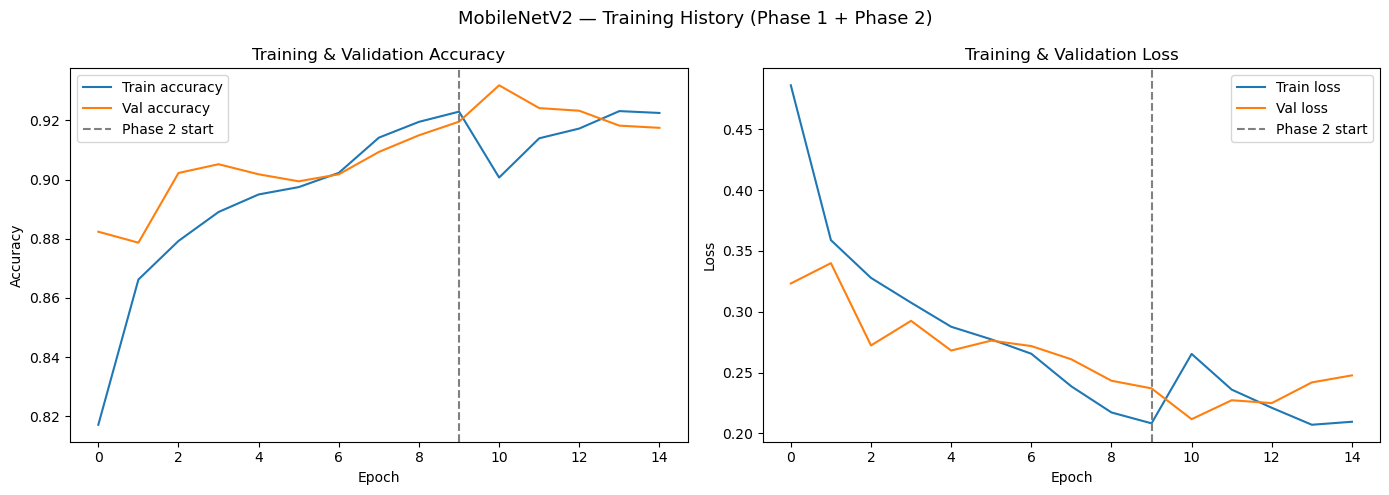

In [9]:
# ════════════════════════════════════════════════════════════
# STEP 7 — PLOT TRAINING HISTORY
# ════════════════════════════════════════════════════════════
def plot_history(h1, h2, metric, ax):
    full_train  = h1.history[metric] + h2.history[metric]
    full_val    = h1.history[f"val_{metric}"] + h2.history[f"val_{metric}"]
    split_epoch = len(h1.history[metric])

    ax.plot(full_train, label=f"Train {metric}")
    ax.plot(full_val,   label=f"Val {metric}")
    ax.axvline(x=split_epoch - 1, color="gray", linestyle="--", label="Phase 2 start")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f"Training & Validation {metric.capitalize()}")
    ax.legend()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_history(history1, history2, "accuracy", ax1)
plot_history(history1, history2, "loss", ax2)
plt.suptitle("MobileNetV2 — Training History (Phase 1 + Phase 2)", fontsize=13)
plt.tight_layout()
plt.show()


Evaluating on Test Data...
211/211 ━━━━━━━━━━━━━━━━━━━━ 56s 266ms/step - accuracy: 0.9318 - loss: 0.2117
Final Test Accuracy: 93.18%
Generating predictions...
211/211 ━━━━━━━━━━━━━━━━━━━━ 59s 277ms/step

--- Classification Report ---
                precision    recall  f1-score   support

Non-Recyclable       0.83      0.88      0.86       970
       Organic       0.97      0.94      0.95      2794
    Recyclable       0.94      0.94      0.94      2985

      accuracy                           0.93      6749
     macro avg       0.91      0.92      0.92      6749
  weighted avg       0.93      0.93      0.93      6749


--- Confusion Matrix ---


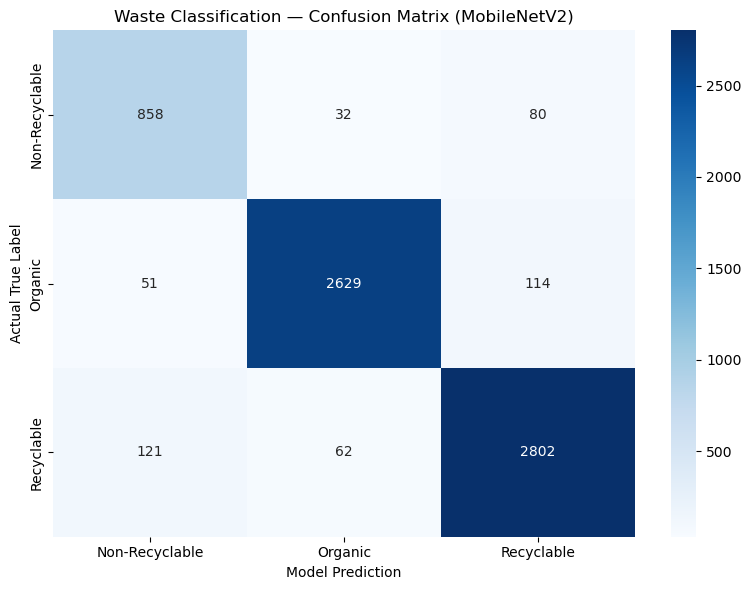

In [10]:
# ════════════════════════════════════════════════════════════
# STEP 8 — EVALUATION
# ════════════════════════════════════════════════════════════
print("\nEvaluating on Test Data...")
test_loss, test_accuracy = model.evaluate(test_gen)
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

true_labels = test_gen.classes
print("Generating predictions...")
predictions      = model.predict(test_gen)
predicted_labels = np.argmax(predictions, axis=1)

print("\n--- Classification Report ---")
print(classification_report(true_labels, predicted_labels, target_names=DISPLAY_NAMES))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=DISPLAY_NAMES, yticklabels=DISPLAY_NAMES)
plt.title("Waste Classification — Confusion Matrix (MobileNetV2)")
plt.ylabel("Actual True Label")
plt.xlabel("Model Prediction")
plt.tight_layout()
plt.show()


In [13]:
# ════════════════════════════════════════════════════════════
# STEP 9 — SAVE MODEL
# ════════════════════════════════════════════════════════════
MODEL_SAVE_PATH = r"C:\Users\Adit Gupta\OneDrive\Desktop\sem 4\practicum\waste_mobilenetv2_final.keras"
print(f"\nSaving to: {os.path.abspath(MODEL_SAVE_PATH)}")
model.save(MODEL_SAVE_PATH)
print(f"Model saved as '{MODEL_SAVE_PATH}' ✅")


Saving to: C:\Users\Adit Gupta\OneDrive\Desktop\sem 4\practicum\waste_mobilenetv2_final.keras
Model saved as 'C:\Users\Adit Gupta\OneDrive\Desktop\sem 4\practicum\waste_mobilenetv2_final.keras' ✅
